# Phase 2 — Exploratory Data Analysis

**Business Goal:** Understand hospital operations, financial performance, and data reliability before deploying AI models.

| # | Section |
|---|---|
| 1 | Setup & Data Load |
| 2 | Dataset Overview |
| 3 | Missing Value Analysis |
| 4 | Distribution Analysis |
| 5 | Outlier Detection |
| 6 | Key Findings |

## 1. Setup & Data Load

In [3]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_theme(style='whitegrid', palette='muted')

DB_PATH = Path('..') / 'HospitalManagementDB.sqlite'
print('Libraries loaded.')

Libraries loaded.


In [4]:
conn = sqlite3.connect(DB_PATH)
patients = pd.read_sql('SELECT * FROM patients', conn)
visits   = pd.read_sql('SELECT * FROM visits',   conn)
billing  = pd.read_sql('SELECT * FROM billing',  conn)
conn.close()

# Parse date columns
patients['registration_date'] = pd.to_datetime(patients['registration_date'])
visits['visit_date']          = pd.to_datetime(visits['visit_date'])
billing['billing_date']       = pd.to_datetime(billing['billing_date'])

# Combined flat table for analysis
df = (
    visits
    .merge(billing,  on='visit_id',  how='left')
    .merge(patients, on='patient_id', how='left')
)

print(f'patients : {len(patients):,} rows x {patients.shape[1]} cols')
print(f'visits   : {len(visits):,} rows x {visits.shape[1]} cols')
print(f'billing  : {len(billing):,} rows x {billing.shape[1]} cols')
print(f'combined : {df.shape[0]:,} rows x {df.shape[1]} cols')

patients : 5,000 rows x 7 cols
visits   : 25,000 rows x 8 cols
billing  : 25,000 rows x 7 cols
combined : 25,000 rows x 20 cols


## 2. Dataset Overview

In [5]:
df.dtypes.rename('dtype').to_frame()

,dtype
visit_id,int64
patient_id,int64
visit_date,datetime64[us]
department,str
visit_type,str
length_of_stay_hours,float64
risk_score,str
doctor_id,int64
bill_id,int64
billed_amount,float64


In [6]:
df.head()

,visit_id,patient_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date,age,gender,city,insurance_provider,chronic_flag,registration_date
0,1,756,2025-10-18,Cardiology,ER,3.48,Low,169,1,"23,577.37",0.00,Rejected,16.00,2025-06-18,90,M,Bangalore,CareOne,1,2025-08-14
1,2,4102,2025-04-06,Orthopedics,OPD,15.31,High,148,2,"38,178.81","38,178.81",Paid,18.00,2025-10-09,30,M,Hyderabad,SecureLife,1,2025-10-29
2,3,2964,2025-07-13,ICU,ER,34.36,Low,153,3,"5,038.97","5,038.97",Paid,NaN,2025-01-20,25,F,Chennai,HealthPlus,1,2025-07-04
3,4,4496,2025-11-19,Cardiology,ER,37.89,High,119,4,"22,813.34","22,813.34",Paid,16.00,2025-12-24,75,M,Delhi,MediCareX,0,2026-01-20
4,5,1930,2025-03-29,General,ICU,16.78,Medium,118,5,"27,106.95","27,106.95",Paid,14.00,2025-09-23,80,M,Bangalore,HealthPlus,1,2025-03-29


In [7]:
numeric_cols = ['length_of_stay_hours', 'billed_amount', 'approved_amount', 'payment_days', 'age']
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
length_of_stay_hours,"25,000.00",19.55,12.31,0.50,9.96,18.20,27.31,78.42
billed_amount,"25,000.00","20,870.76","12,606.29",500.00,"11,582.45","19,644.85","28,398.07","88,539.01"
approved_amount,"23,682.00","16,348.11","13,778.80",0.00,"4,603.07","14,379.65","24,845.02","88,539.01"
payment_days,"24,210.00",13.05,7.24,1.00,8.00,13.00,17.00,55.00
age,"25,000.00",44.77,17.78,1.00,33.00,45.00,57.00,90.00


In [8]:
cat_cols = ['department', 'visit_type', 'risk_score', 'claim_status', 'insurance_provider', 'city', 'gender']
for col in cat_cols:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print()

--- department ---
department
General        4228
ER             4220
Neurology      4165
Orthopedics    4164
Cardiology     4159
ICU            4064
Name: count, dtype: int64

--- visit_type ---
visit_type
ER     8382
OPD    8381
ICU    8237
Name: count, dtype: int64

--- risk_score ---
risk_score
Low       12470
Medium     7496
High       5034
Name: count, dtype: int64

--- claim_status ---
claim_status
Paid        14940
Pending      6263
Rejected     3797
Name: count, dtype: int64

--- insurance_provider ---
insurance_provider
MediCareX     6532
CareOne       6283
HealthPlus    6220
SecureLife    5965
Name: count, dtype: int64

--- city ---
city
Hyderabad    4370
Pune         4221
Bangalore    4205
Mumbai       4122
Delhi        4107
Chennai      3975
Name: count, dtype: int64

--- gender ---
gender
F    12739
M    12261
Name: count, dtype: int64



## 3. Missing Value Analysis

Focus on the three fields with data-quality risk: `approved_amount`, `payment_days`, `length_of_stay_hours`.

In [9]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
mv_summary = pd.concat([missing.rename('missing_count'), missing_pct.rename('missing_pct_%')], axis=1)
mv_summary[mv_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)

,missing_count,missing_pct_%
approved_amount,1318,5.27
payment_days,790,3.16


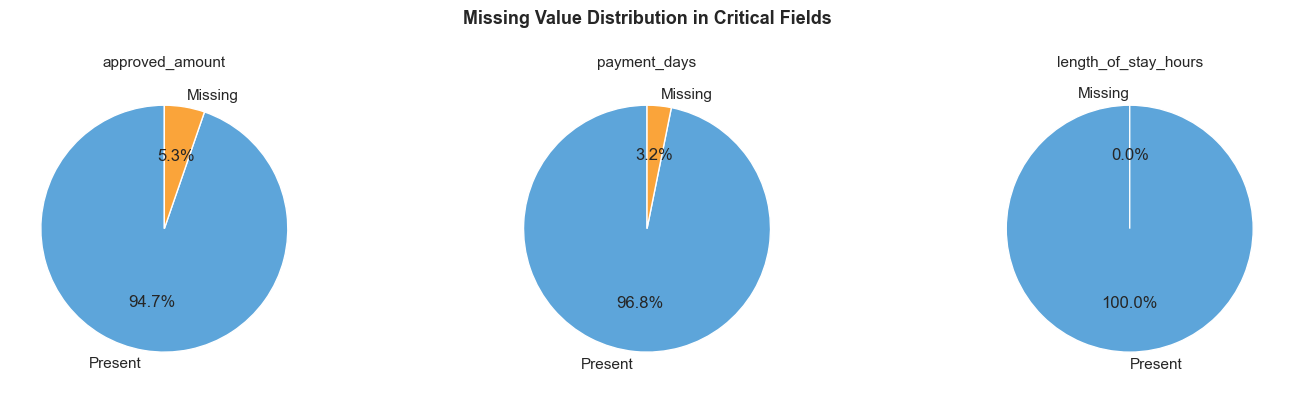

In [10]:
focus_cols = ['approved_amount', 'payment_days', 'length_of_stay_hours']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, focus_cols):
    present = df[col].notna().sum()
    missing_n = df[col].isna().sum()
    ax.pie(
        [present, missing_n],
        labels=['Present', 'Missing'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#5DA5DA', '#FAA43A'],
    )
    ax.set_title(col, fontsize=11)

plt.suptitle('Missing Value Distribution in Critical Fields', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Is missingness in approved_amount / payment_days linked to claim_status?
print('=== approved_amount: null count by claim_status ===')
print(df.groupby('claim_status')['approved_amount'].apply(lambda s: s.isna().sum()))
print()
print('=== approved_amount == 0 count by claim_status ===')
print(df[df['approved_amount'] == 0]['claim_status'].value_counts())
print()
print('=== payment_days: null count by claim_status ===')
print(df.groupby('claim_status')['payment_days'].apply(lambda s: s.isna().sum()))

=== approved_amount: null count by claim_status ===
claim_status
Paid        817
Pending     301
Rejected    200
Name: approved_amount, dtype: int64

=== approved_amount == 0 count by claim_status ===
claim_status
Rejected    3597
Name: count, dtype: int64

=== payment_days: null count by claim_status ===
claim_status
Paid        459
Pending     208
Rejected    123
Name: payment_days, dtype: int64


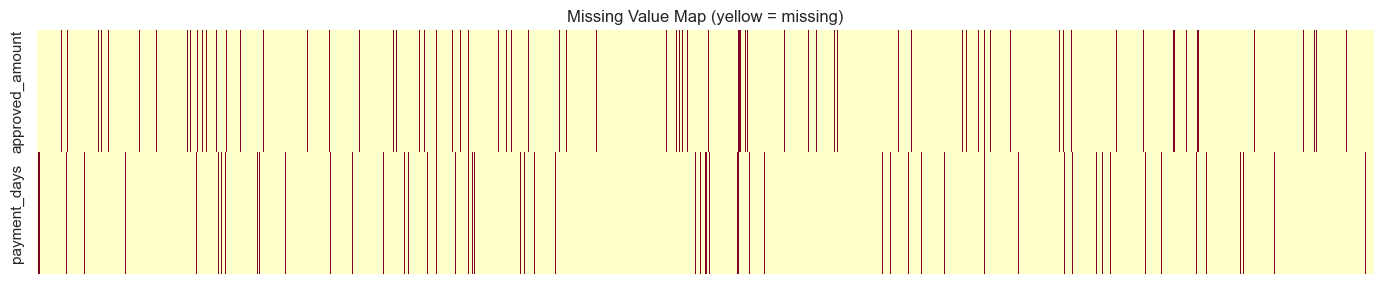

In [12]:
# Missingness heatmap across all columns
plt.figure(figsize=(14, 3))
mask = df.isnull()
cols_with_nulls = mask.columns[mask.any()].tolist()
if cols_with_nulls:
    sns.heatmap(
        mask[cols_with_nulls].T,
        cbar=False,
        yticklabels=cols_with_nulls,
        xticklabels=False,
        cmap='YlOrRd',
    )
    plt.title('Missing Value Map (yellow = missing)', fontsize=12)
else:
    print('No missing values found outside approved_amount and payment_days.')
plt.tight_layout()
plt.show()

## 4. Distribution Analysis

### 4.1 By Department

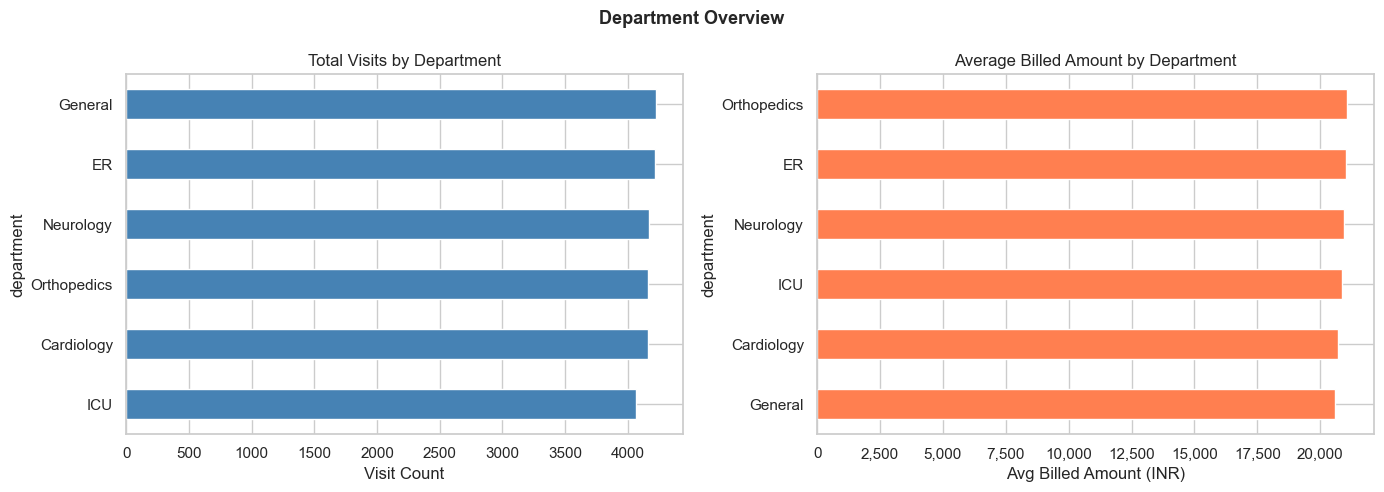

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Visit volume
dept_counts = df['department'].value_counts().sort_values(ascending=True)
dept_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Total Visits by Department')
axes[0].set_xlabel('Visit Count')

# Average billed amount
dept_billed = df.groupby('department')['billed_amount'].mean().sort_values(ascending=True)
dept_billed.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Average Billed Amount by Department')
axes[1].set_xlabel('Avg Billed Amount (INR)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Department Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dept_overview.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Adarsh S S\AppData\Local\Temp\ipykernel_4700\2064436037.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=high_risk_rate, x='department', y='high_risk_pct', palette='Reds_d')


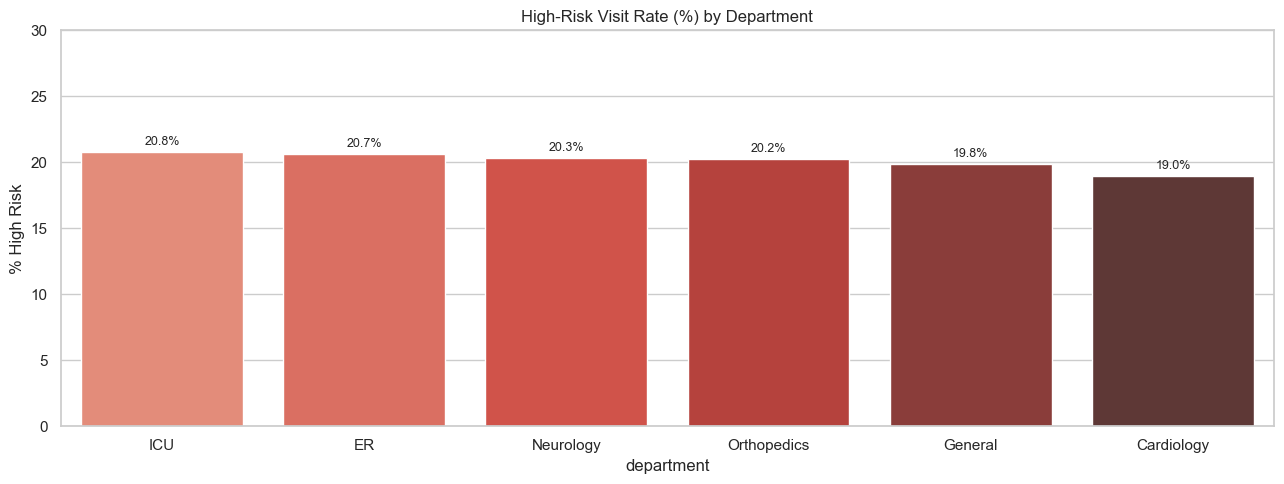

 department  high_risk_pct
        ICU          20.79
         ER          20.66
  Neurology          20.31
Orthopedics          20.22
    General          19.84
 Cardiology          18.99


In [14]:
# High-risk visit rate by department
high_risk_rate = (
    df.groupby('department')['risk_score']
    .apply(lambda s: (s == 'High').mean() * 100)
    .round(2)
    .rename('high_risk_pct')
    .sort_values(ascending=False)
    .reset_index()
)

ax = sns.barplot(data=high_risk_rate, x='department', y='high_risk_pct', palette='Reds_d')
ax.set_title('High-Risk Visit Rate (%) by Department', fontsize=12)
ax.set_ylabel('% High Risk')
ax.set_ylim(0, 30)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
print(high_risk_rate.to_string(index=False))

C:\Users\Adarsh S S\AppData\Local\Temp\ipykernel_4700\1431343136.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='department', y='length_of_stay_hours', palette='pastel', showfliers=False)


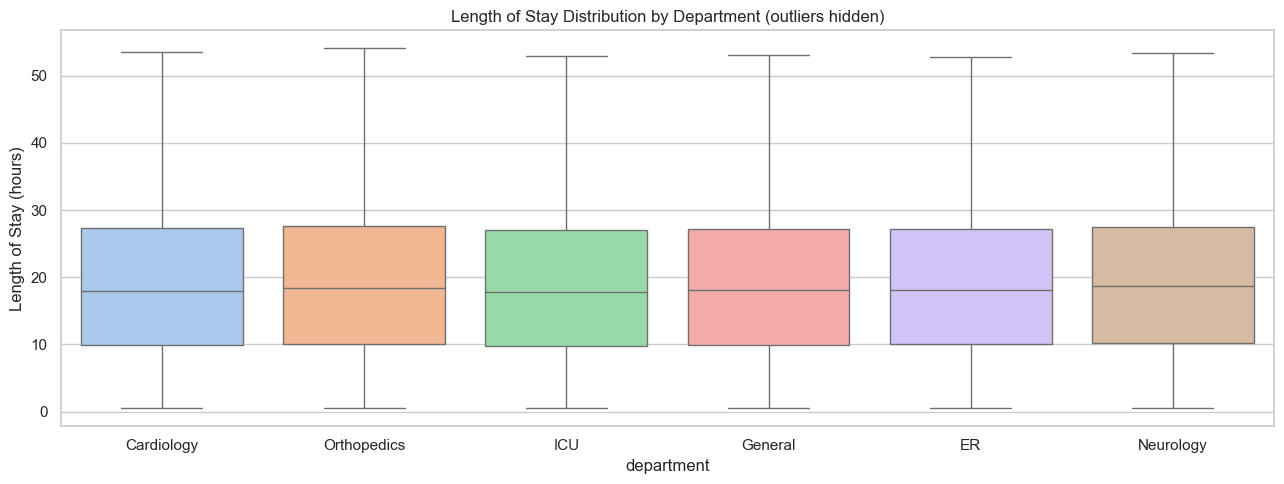

In [15]:
# Length of stay distribution by department
plt.figure(figsize=(13, 5))
sns.boxplot(data=df, x='department', y='length_of_stay_hours', palette='pastel', showfliers=False)
plt.title('Length of Stay Distribution by Department (outliers hidden)', fontsize=12)
plt.ylabel('Length of Stay (hours)')
plt.tight_layout()
plt.savefig('los_by_dept.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 By Visit Type

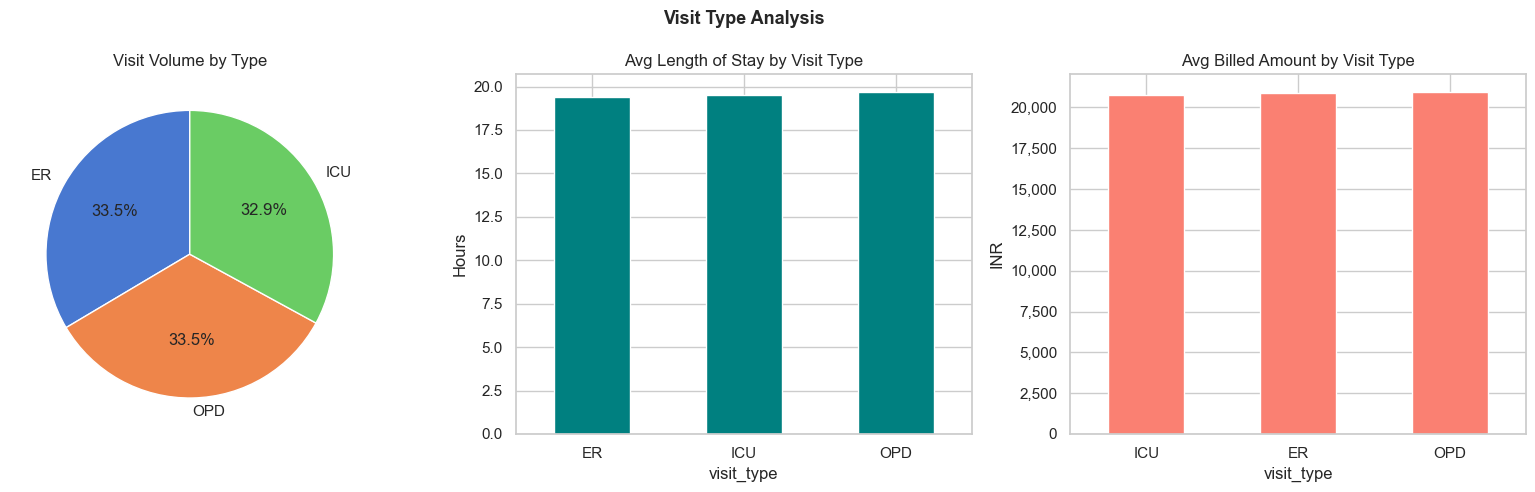

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Volume
vt_counts = df['visit_type'].value_counts()
axes[0].pie(vt_counts, labels=vt_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Visit Volume by Type')

# Avg LOS
vt_los = df.groupby('visit_type')['length_of_stay_hours'].mean().sort_values()
vt_los.plot(kind='bar', ax=axes[1], color='teal', rot=0)
axes[1].set_title('Avg Length of Stay by Visit Type')
axes[1].set_ylabel('Hours')

# Avg billed amount
vt_billed = df.groupby('visit_type')['billed_amount'].mean().sort_values()
vt_billed.plot(kind='bar', ax=axes[2], color='salmon', rot=0)
axes[2].set_title('Avg Billed Amount by Visit Type')
axes[2].set_ylabel('INR')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Visit Type Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visit_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 By Insurance Provider

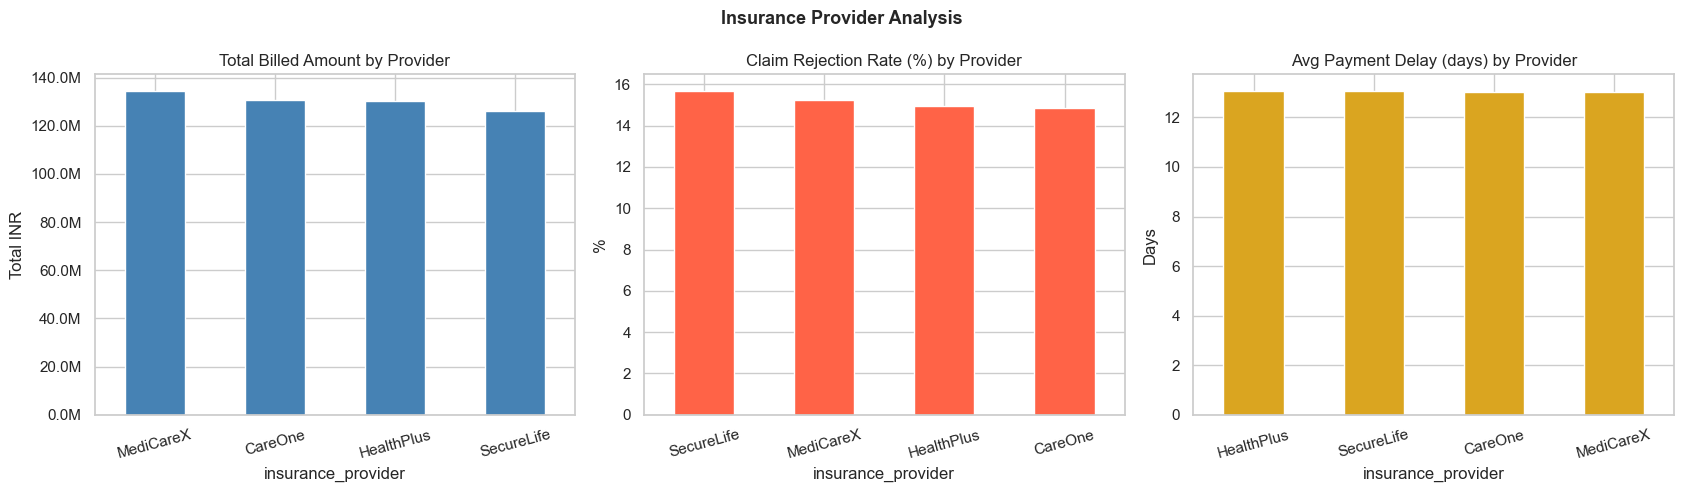

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Total billed amount
prov_billed = df.groupby('insurance_provider')['billed_amount'].sum().sort_values(ascending=False)
prov_billed.plot(kind='bar', ax=axes[0], color='steelblue', rot=15)
axes[0].set_title('Total Billed Amount by Provider')
axes[0].set_ylabel('Total INR')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Rejection rate
reject_rate = (
    df.groupby('insurance_provider')['claim_status']
    .apply(lambda s: (s == 'Rejected').mean() * 100)
    .sort_values(ascending=False)
)
reject_rate.plot(kind='bar', ax=axes[1], color='tomato', rot=15)
axes[1].set_title('Claim Rejection Rate (%) by Provider')
axes[1].set_ylabel('%')

# Avg payment days
prov_pay = df.groupby('insurance_provider')['payment_days'].mean().sort_values(ascending=False)
prov_pay.plot(kind='bar', ax=axes[2], color='goldenrod', rot=15)
axes[2].set_title('Avg Payment Delay (days) by Provider')
axes[2].set_ylabel('Days')

plt.suptitle('Insurance Provider Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('provider_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
provider_summary = df.groupby('insurance_provider').agg(
    total_claims   = ('bill_id', 'count'),
    rejected_claims= ('claim_status', lambda s: (s == 'Rejected').sum()),
    rejection_rate = ('claim_status', lambda s: round((s == 'Rejected').mean() * 100, 2)),
    avg_billed     = ('billed_amount', 'mean'),
    avg_approved   = ('approved_amount', 'mean'),
    avg_payment_days = ('payment_days', 'mean'),
).reset_index()
provider_summary

,insurance_provider,total_claims,rejected_claims,rejection_rate,avg_billed,avg_approved,avg_payment_days
0,CareOne,6283,934,14.87,"20,803.44","16,304.88",13.03
1,HealthPlus,6220,931,14.97,"20,929.38","16,388.86",13.08
2,MediCareX,6532,996,15.25,"20,604.89","16,156.09",13.01
3,SecureLife,5965,936,15.69,"21,171.67","16,561.44",13.08


### 4.4 By City

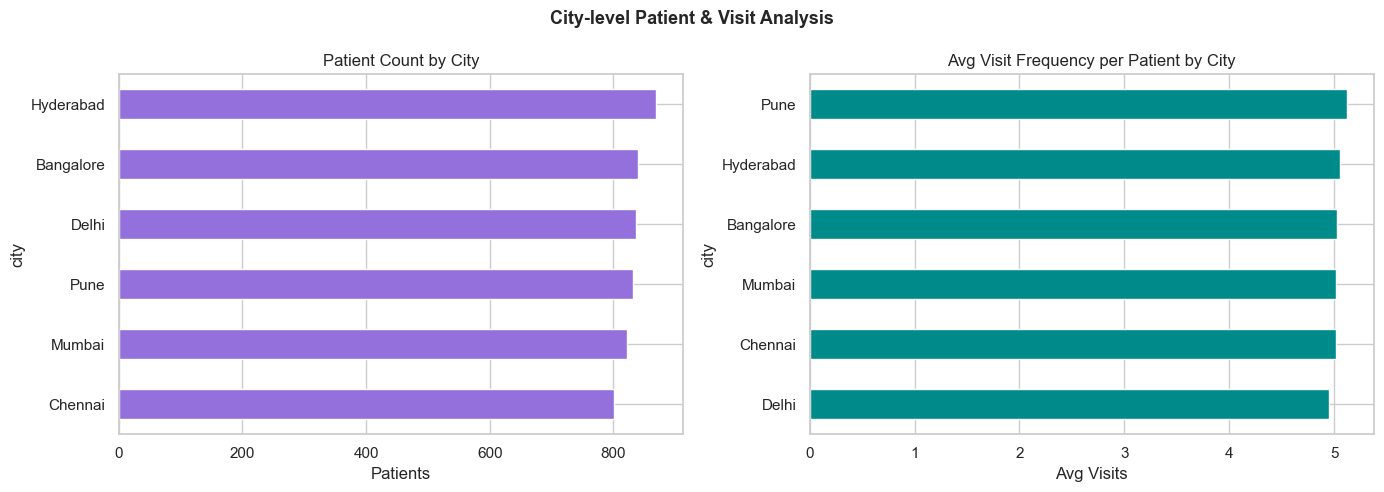

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Patient count per city
city_patients = patients['city'].value_counts().sort_values(ascending=True)
city_patients.plot(kind='barh', ax=axes[0], color='mediumpurple')
axes[0].set_title('Patient Count by City')
axes[0].set_xlabel('Patients')

# Avg visit frequency per patient by city
visit_freq = df.groupby('patient_id')['visit_id'].count().rename('visit_frequency')
city_freq = (
    patients
    .merge(visit_freq, on='patient_id', how='left')
    .groupby('city')['visit_frequency']
    .mean()
    .sort_values(ascending=True)
)
city_freq.plot(kind='barh', ax=axes[1], color='darkcyan')
axes[1].set_title('Avg Visit Frequency per Patient by City')
axes[1].set_xlabel('Avg Visits')

plt.suptitle('City-level Patient & Visit Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('city_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Chronic patient rate by city
chronic_rate = (
    patients
    .groupby('city')['chronic_flag']
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
    .rename('chronic_pct')
)
print('Chronic patient rate (%) by city:')
print(chronic_rate.to_frame())

Chronic patient rate (%) by city:
           chronic_pct
city                  
Pune             53.50
Bangalore        50.60
Mumbai           50.20
Hyderabad        50.10
Chennai          49.30
Delhi            49.10


## 5. Outlier Detection

Using the **IQR method**: outlier threshold = Q1 − 1.5×IQR (lower) and Q3 + 1.5×IQR (upper).

In [21]:
def iqr_bounds(series: pd.Series) -> tuple:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


def outlier_summary(df: pd.DataFrame, col: str) -> pd.Series:
    series = df[col].dropna()
    lo, hi = iqr_bounds(series)
    n_low  = (series < lo).sum()
    n_high = (series > hi).sum()
    n_total = len(series)
    return pd.Series({
        'count': n_total,
        'mean': series.mean(),
        'std': series.std(),
        'min': series.min(),
        'Q1': series.quantile(0.25),
        'median': series.median(),
        'Q3': series.quantile(0.75),
        'max': series.max(),
        'lower_fence': lo,
        'upper_fence': hi,
        'n_low_outliers': n_low,
        'n_high_outliers': n_high,
        'outlier_pct': round((n_low + n_high) / n_total * 100, 2),
    })


outlier_cols = ['billed_amount', 'payment_days', 'length_of_stay_hours']
outlier_stats = pd.DataFrame({c: outlier_summary(df, c) for c in outlier_cols})
outlier_stats

,billed_amount,payment_days,length_of_stay_hours
count,"25,000.00","24,210.00","25,000.00"
mean,"20,870.76",13.05,19.55
std,"12,606.29",7.24,12.31
min,500.00,1.00,0.50
Q1,"11,582.45",8.00,9.96
median,"19,644.85",13.00,18.20
Q3,"28,398.07",17.00,27.31
max,"88,539.01",55.00,78.42
lower_fence,"-13,640.97",-5.50,-16.07
upper_fence,"53,621.49",30.50,53.34


C:\Users\Adarsh S S\AppData\Local\Temp\ipykernel_4700\4055793299.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='department', y='billed_amount', ax=axes[1], palette='Set2')


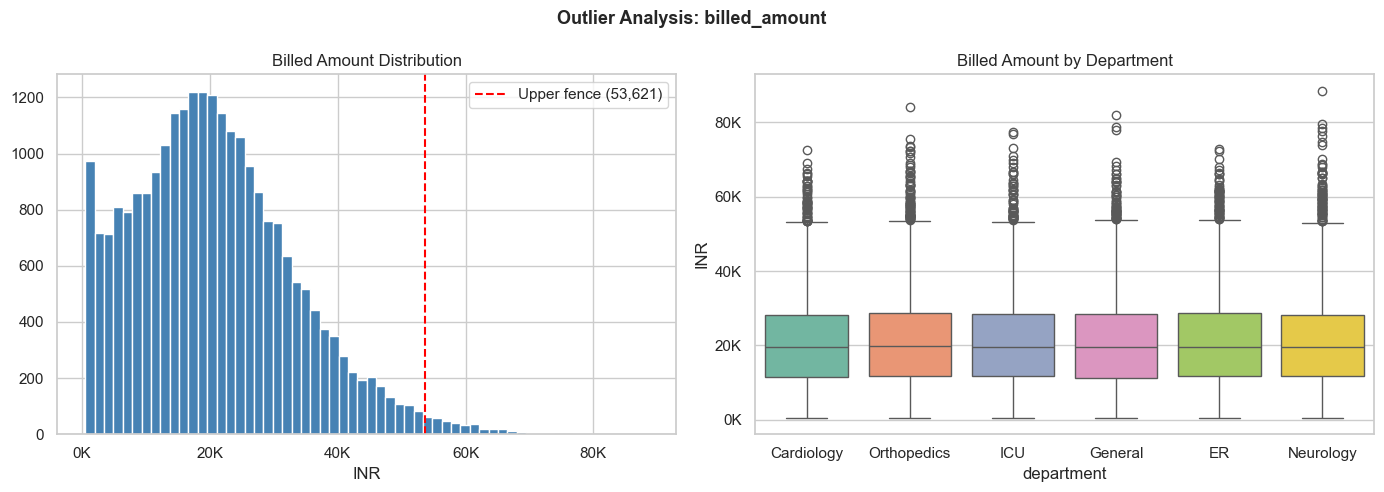

High outliers (billed_amount > 53,621): 373 records (1.5%)


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['billed_amount'].dropna(), bins=60, color='steelblue', edgecolor='white')
lo, hi = iqr_bounds(df['billed_amount'].dropna())
axes[0].axvline(hi, color='red', linestyle='--', label=f'Upper fence ({hi:,.0f})')
axes[0].set_title('Billed Amount Distribution')
axes[0].set_xlabel('INR')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].legend()

# Box plot by department
sns.boxplot(data=df, x='department', y='billed_amount', ax=axes[1], palette='Set2')
axes[1].set_title('Billed Amount by Department')
axes[1].set_ylabel('INR')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.suptitle('Outlier Analysis: billed_amount', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outliers_billed.png', dpi=150, bbox_inches='tight')
plt.show()

n_outliers = ((df['billed_amount'] > hi)).sum()
print(f'High outliers (billed_amount > {hi:,.0f}): {n_outliers:,} records ({n_outliers/len(df)*100:.1f}%)')

C:\Users\Adarsh S S\AppData\Local\Temp\ipykernel_4700\3982879461.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.dropna(subset=['payment_days']), x='insurance_provider', y='payment_days',


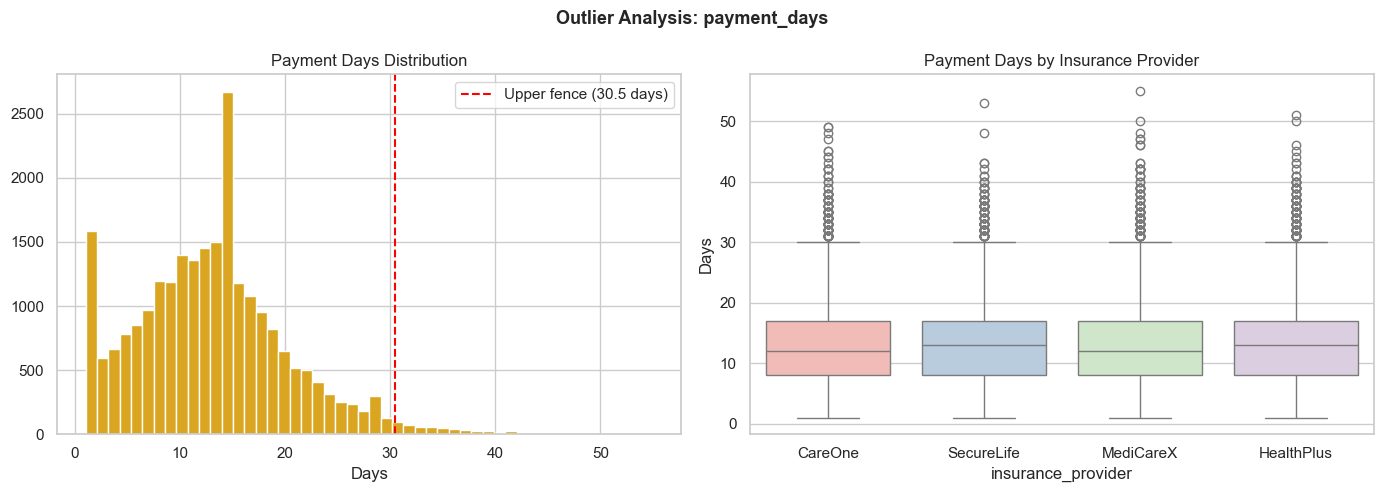

High outliers (payment_days > 30.5): 509 records (2.1%)


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd_series = df['payment_days'].dropna()
lo_pd, hi_pd = iqr_bounds(pd_series)

# Histogram
axes[0].hist(pd_series, bins=50, color='goldenrod', edgecolor='white')
axes[0].axvline(hi_pd, color='red', linestyle='--', label=f'Upper fence ({hi_pd:.1f} days)')
axes[0].set_title('Payment Days Distribution')
axes[0].set_xlabel('Days')
axes[0].legend()

# Box plot by provider
sns.boxplot(data=df.dropna(subset=['payment_days']), x='insurance_provider', y='payment_days',
            ax=axes[1], palette='Pastel1')
axes[1].set_title('Payment Days by Insurance Provider')
axes[1].set_ylabel('Days')

plt.suptitle('Outlier Analysis: payment_days', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outliers_payment_days.png', dpi=150, bbox_inches='tight')
plt.show()

n_outliers_pd = (pd_series > hi_pd).sum()
print(f'High outliers (payment_days > {hi_pd:.1f}): {n_outliers_pd:,} records ({n_outliers_pd/len(pd_series)*100:.1f}%)')

C:\Users\Adarsh S S\AppData\Local\Temp\ipykernel_4700\3223184650.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='visit_type', y='length_of_stay_hours', ax=axes[1], palette='Set3')


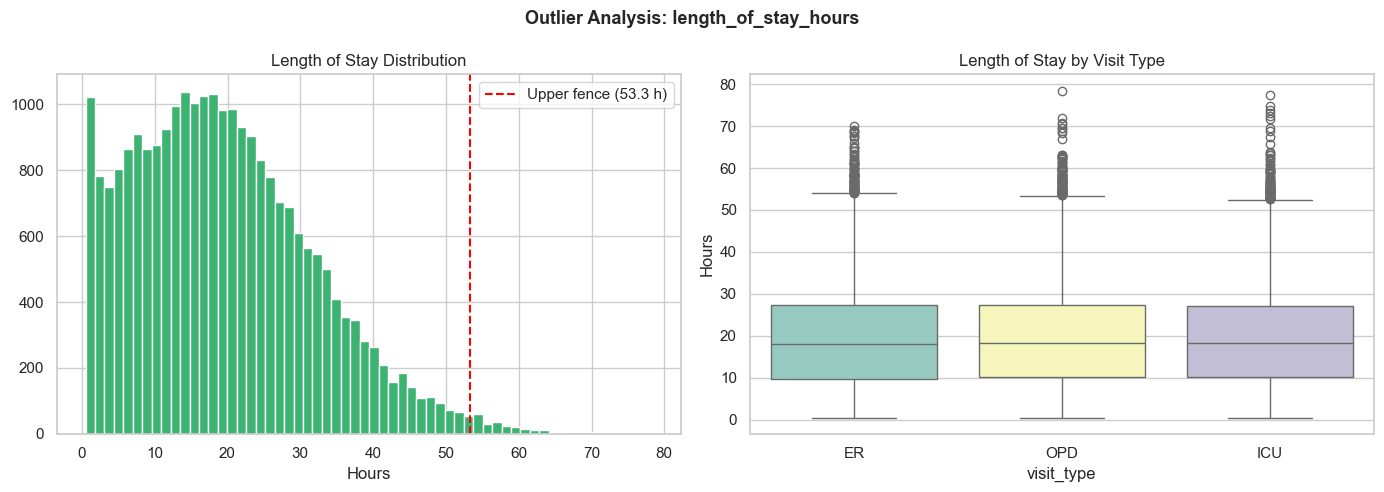

High outliers (LOS > 53.3 h): 256 records (1.0%)


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

los_series = df['length_of_stay_hours'].dropna()
lo_los, hi_los = iqr_bounds(los_series)

# Histogram
axes[0].hist(los_series, bins=60, color='mediumseagreen', edgecolor='white')
axes[0].axvline(hi_los, color='red', linestyle='--', label=f'Upper fence ({hi_los:.1f} h)')
axes[0].set_title('Length of Stay Distribution')
axes[0].set_xlabel('Hours')
axes[0].legend()

# Box plot by visit type
sns.boxplot(data=df, x='visit_type', y='length_of_stay_hours', ax=axes[1], palette='Set3')
axes[1].set_title('Length of Stay by Visit Type')
axes[1].set_ylabel('Hours')

plt.suptitle('Outlier Analysis: length_of_stay_hours', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outliers_los.png', dpi=150, bbox_inches='tight')
plt.show()

n_outliers_los = (los_series > hi_los).sum()
print(f'High outliers (LOS > {hi_los:.1f} h): {n_outliers_los:,} records ({n_outliers_los/len(los_series)*100:.1f}%)')

In [25]:
# Classify each outlier row and inspect context
lo_ba, hi_ba   = iqr_bounds(df['billed_amount'].dropna())
lo_pd2, hi_pd2 = iqr_bounds(df['payment_days'].dropna())
lo_ls, hi_ls   = iqr_bounds(df['length_of_stay_hours'].dropna())

df['outlier_billed']  = (df['billed_amount'] > hi_ba).astype(int)
df['outlier_payment'] = (df['payment_days']  > hi_pd2).astype(int)
df['outlier_los']     = (df['length_of_stay_hours'] > hi_ls).astype(int)

print('Outlier count per flag:')
print(df[['outlier_billed', 'outlier_payment', 'outlier_los']].sum().to_frame('count'))

print('\nDepartment breakdown for high billed_amount outliers:')
print(df[df['outlier_billed'] == 1]['department'].value_counts())

print('\nClaim status breakdown for long payment_days outliers:')
print(df[df['outlier_payment'] == 1]['claim_status'].value_counts())

Outlier count per flag:
                 count
outlier_billed     373
outlier_payment    509
outlier_los        256

Department breakdown for high billed_amount outliers:
department
Orthopedics    75
Neurology      72
General        62
ER             62
ICU            54
Cardiology     48
Name: count, dtype: int64

Claim status breakdown for long payment_days outliers:
claim_status
Pending     339
Rejected    142
Paid         28
Name: count, dtype: int64


## 6. Key Findings

### Data Quality
- **`approved_amount = 0.0` is a business state** (Rejected), not missing data. True NULLs represent Pending claims.
- **`payment_days` NULLs are tied to claim status** — Rejected and Pending claims have no payment date yet; dropping these rows creates survivorship bias.
- **`length_of_stay_hours` is complete** with no nulls or negatives; extreme highs are clinically valid ICU stays.

### Operational Patterns
- Visit volume is **evenly distributed across 6 departments** (~4,000–4,200 each) — no class imbalance issue for department-level modelling.
- High-risk visit rate is **near-uniform (~19–21%)** across departments, suggesting risk is driven by patient characteristics (age, chronic_flag), not department.
- Average visit frequency is **~5 visits per patient** across all cities — consistent cohort.

### Financial Patterns
- **Rejection rates vary by insurer** — this is the primary revenue-leakage signal and the most actionable model target.
- **Billed amount is right-skewed** with ~5% outliers; ICU and Cardiology contribute the highest-value claims.
- **Payment delay distribution varies by provider** — some providers average significantly more days, which represents a cash-flow risk.

### Outlier Classification

| Field | Outlier Type | Action |
|-------|-------------|--------|
| `billed_amount` | Plausible extremes (complex procedures) | Log-transform or winsorize at 99th pct |
| `payment_days` | Disputed / escalated claims | Flag as `long_payment_delay`; retain in dataset |
| `length_of_stay_hours` | ICU / surgery cases | Cap only for distance-based models; raw for trees |




## Runing `build_features.py` to generate `model_table.csv`.

In [27]:
# execute build_features.py to generate features and save to CSV and Parquet by calling main() function

import build_features as build_features

df = build_features.main(df)

print("\nFeature engineering completed.")
print(f"Final dataframe shape: {df.shape}")


Engineering features...
  Final shape : (25000, 34)
  New features: ['visit_month', 'visit_quarter', 'visit_dayofweek', 'is_weekend', 'days_since_registration', 'billing_lag', 'visit_frequency', 'avg_los_per_patient', 'provider_rejection_rate', 'dept_avg_billed', 'approval_ratio']

Saving CSV     : c:\AIML-IITM\Capstone Project\Phase2_EDA\model_table.csv
Saving Parquet : c:\AIML-IITM\Capstone Project\Phase2_EDA\model_table.parquet

Done.

Feature engineering completed.
Final dataframe shape: (25000, 34)
